Imports e caminhos dos dados

In [2]:
import re
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import numpy as np
from IPython.display import display
from plotly.subplots import make_subplots

# Caminhos de entrada
XLSX1_PATH = "../Datos_Anonimo_20231_v2.xlsx"  # 1º semestre
XLSX2_PATH = "../Datos_Anonimo_20232_v2.xlsx"  # 2º semestre
SHEET_INDEX = 1  # segunda aba

Mapeamentos e tokens de erro

In [3]:
# Renomeação de colunas ES -> PT (sem acentos nos nomes de colunas para evitar problemas)
rename_map = {
    "Periodo": "Periodo",
    "Grupo": "Grupo",
    "Horario": "Horario",
    "Tipo_Documento": "Tipo_Documento",
    "Edad": "Idade",
    "Genero": "Genero",
    "STEM": "STEM",
    "MejoraNotaQuices": "MelhoraNotaQuizzes",
    "Calificación_Oficial": "Nota_Oficial",
    "Aprobo": "Aprovou",
    "Nombre_Programa_Academico": "Nome_Programa_Academico",
    "Nombre_Programa_Académico": "Nome_Programa_Academico",
    "Proyecto_Parte1": "Projeto_Parte1",
    "Proyecto_Parte2": "Projeto_Parte2",
    "Talleres": "Oficinas",
    "Quices": "Quizzes",
    "CalcNotaQuiz": "CalcNotaQuiz",
    "Parcial_1": "Parcial_1",
    "Parcial_2": "Parcial_2",
    "Quiz1": "Quiz1",
    "Quiz2": "Quiz2",
    "Quiz3": "Quiz3",
    "Quiz4": "Quiz4",
    "Quiz5": "Quiz5",
    "Quiz6": "Quiz6",
    "Quiz7": "Quiz7",
    "Quiz8": "Quiz8",
    "Cuánto mejora?": "Quanto_Melhora",
    "Cuanto mejora?": "Quanto_Melhora",
}
# N mínimo prático para o dataset atual: 8 (fecha/tiempo 1..8)
for i in range(1, 9):
    rename_map[f"Fecha_Quiz{i}"] = f"Data_Quiz{i}"
    rename_map[f"TiempoQ{i}"] = f"TempoQ{i}"

MAPA_PROGRAMAS = {
    "COMUNICACIÓN SOCIAL": "Comunicacao Social",
    "DERECHO": "Direito",
    "INGENIERÍA CIVIL": "Engenharia Civil",
    "ADMINISTRACIÓN DE NEGOCIOS": "Administracao de Negocios",
    "INGENIERÍA DE DISEÑO DE PRODUCTO": "Engenharia de Design de Produto",
    "MERCADEO": "Marketing",
    "PSICOLOGÍA": "Psicologia",
    "INGENIERÍA FÍSICA": "Engenharia Fisica",
    "NEGOCIOS INTERNACIONALES": "Negocios Internacionais",
    "BIOLOGÍA": "Biologia",
    "CIENCIAS POLÍTICAS": "Ciencias Politicas",
    "ECONOMÍA": "Economia",
    "CONTADURÍA PÚBLICA": "Contabilidade Publica",
    "MÚSICA": "Musica",
    "LITERATURA": "Literatura",
    "INGENIERÍA DE PROCESOS": "Engenharia de Processos",
    "CONVENIO MOVILIDAD PREGRADO (CONVENIOS - MOVILIDAD NACIONAL - ASISTENTES PREGRADO)":
        "Convenio Mobilidade Graduacao (Convenios - Mobilidade Nacional - Assistentes Graduacao)",
}
MAPA_APROV = {"Aprobó": "Aprovou", "Reprobó": "Reprovou", "Aprobo": "Aprovou", "Reprobo": "Reprovou"}
MAPA_IDADE = {"Mayor": "Maior", "Menor": "Menor"}
MAPA_GENERO = {"femenino": "Feminino", "masculino": "Masculino", "Femenino": "Feminino", "Masculino": "Masculino"}

# Padronização de STEM para PT: "Sim" / "No"
MAPA_STEM = {
    "Sí": "Sim", "SÍ": "Sim", "si": "Sim", "SIM": "Sim", "Sim": "Sim",
    "YES": "Sim", "Yes": "Sim", "TRUE": "Sim", "True": "Sim", "1": "Sim",
    "No": "No", "NO": "No", "Nao": "No", "Não": "No", "nao": "No",
    "FALSE": "No", "False": "No", "0": "No",
}

ERROR_TOKENS = {
    "#ERROR!", "#DIV/0!", "#N/A", "#NAME?", "#NULL!", "#NUM!", "#VALUE!", "#REF!",
    "N/D", "N/A", "NA", "NaN", "nan", "None", "NONE"
}

Funções utilitárias (limpeza, padronização, tempos, presença, one-hot e estatísticas)

In [4]:
# Limpar células com error
def replace_excel_errors(df, cols=None):
    df = df.copy()
    if cols is None:
        cols = df.select_dtypes(include="object").columns.tolist()
    for c in cols:
        if c in df.columns:
            df[c] = df[c].replace(list(ERROR_TOKENS), np.nan)
    return df

# Padronização do dataframe
def padroniza_df(df):
    df = df.copy().rename(columns=rename_map)
    df = replace_excel_errors(df)
    if "Nome_Programa_Academico" in df.columns:
        df["Nome_Programa_Academico"] = (
            df["Nome_Programa_Academico"].astype(str).str.strip().replace(MAPA_PROGRAMAS, regex=False)
        )
    if "Aprovou" in df.columns:
        df["Aprovou"] = df["Aprovou"].astype(str).str.strip().replace(MAPA_APROV, regex=False)
    if "Idade" in df.columns:
        df["Idade"] = df["Idade"].astype(str).str.strip().replace(MAPA_IDADE, regex=False)
    if "Genero" in df.columns:
        df["Genero"] = df["Genero"].astype(str).str.strip().replace(MAPA_GENERO, regex=False)
    if "STEM" in df.columns:
        mask = df["STEM"].notna()
        if mask.any():
            df.loc[mask, "STEM"] = df.loc[mask, "STEM"].astype(str).str.strip().replace(MAPA_STEM, regex=False)
    return df

# Regex para parse de tempo (ex.: "2 minutos 10 segundos")
_PATTERN_TEMPO = re.compile(
    r"^\s*(?:(\d+)\s*minuto(?:s)?)?\s*(?:(\d+)\s*segundo(?:s)?)?\s*$",
    re.IGNORECASE
)

# Normalização dos tempos
def parse_to_seconds(val):
    if pd.isna(val):
        return np.nan
    if isinstance(val, (int, float)) and not isinstance(val, bool):
        try:
            return int(val)
        except Exception:
            return np.nan
    if isinstance(val, str):
        s = val.strip()
        try:
            return int(float(s))
        except Exception:
            pass
        s_norm = s.replace(" e ", " ").replace(",", " ")
        m = _PATTERN_TEMPO.match(s_norm)
        if m:
            mins, secs = m.group(1), m.group(2)
            total = (int(mins) * 60 if mins else 0) + (int(secs) if secs else 0)
            return total if (mins or secs) else np.nan
        if ":" in s_norm:
            parts = [p.strip() for p in s_norm.split(":")]
            if len(parts) == 2 and all(p.isdigit() for p in parts):
                mm, ss = map(int, parts)
                return mm * 60 + ss
            if len(parts) == 3 and all(p.isdigit() for p in parts):
                hh, mm, ss = map(int, parts)
                return hh * 3600 + mm * 60 + ss
    return np.nan

# Padroniza as colunas de tempo
def converte_colunas_tempo(df):
    df = df.copy()
    cols_tempo = [c for c in df.columns if re.match(r"^(TempoQ|TiempoQ)\d+$", c)]
    for col in cols_tempo:
        df[col] = df[col].apply(parse_to_seconds)
    return df

# Remove os alunos faltantes
def filtra_alunos_presentes(df):
    df = df.copy()
    cols_data = [c for c in df.columns if re.match(r"^(Data_Quiz|Fecha_Quiz)\d+$", c)]
    if not cols_data:
        return df
    df_filtrado = df.dropna(subset=cols_data, how="all")
    df_filtrado = df_filtrado.drop(columns=cols_data)
    return df_filtrado

def remove_outliers(df, n_cols_per_row=3):
    df_numeric = df.select_dtypes(include=["number"])
    df_numeric = df_numeric.drop(columns=["Grupo"], errors="ignore")  # evita erro se não existir

    n_cols = len(df_numeric.columns)
    n_rows = math.ceil(n_cols / n_cols_per_row)

    # Boxplots originais
    fig, axes = plt.subplots(n_rows, n_cols_per_row, figsize=(6*n_cols_per_row, 4*n_rows))
    axes = axes.flatten()
    for i, col in enumerate(df_numeric.columns):
        sns.boxplot(x=df_numeric[col], ax=axes[i])
        axes[i].set_title(f"Boxplot - {col}")
    # remover eixos vazios
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])
    plt.tight_layout()
    plt.show()

    # Normalizar os outliers (clip)
    for col in df_numeric.columns:
        Q1 = df_numeric[col].quantile(0.25)
        Q3 = df_numeric[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df_numeric[col] = df_numeric[col].clip(lower, upper)

    # Boxplots limpos
    fig, axes = plt.subplots(n_rows, n_cols_per_row, figsize=(6*n_cols_per_row, 4*n_rows))
    axes = axes.flatten()
    for i, col in enumerate(df_numeric.columns):
        sns.boxplot(x=df_numeric[col], ax=axes[i])
        axes[i].set_title(f"Boxplot cleaned - {col}")
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])
    plt.tight_layout()
    plt.show()

    return df_numeric

def fit_onehot_encoder(df_cat, cat_cols):
    cat_cols_exist = [c for c in cat_cols if c in df_cat.columns]
    if not cat_cols_exist:
        return {"type": "none", "encoder": None, "columns": [], "cat_cols": []}
    X_fit = replace_excel_errors(df_cat[cat_cols_exist].copy(), cols=cat_cols_exist)
    X_fit = X_fit.fillna("MISSING").astype(str)
    try:
        from sklearn.preprocessing import OneHotEncoder
        try:
            enc = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
        except TypeError:
            enc = OneHotEncoder(sparse=False, handle_unknown="ignore")
        enc.fit(X_fit)
        cols = list(enc.get_feature_names_out(cat_cols_exist))
        return {"type": "sklearn", "encoder": enc, "columns": cols, "cat_cols": cat_cols_exist}
    except Exception:
        dummies = pd.get_dummies(X_fit, prefix=cat_cols_exist, dummy_na=False)
        cols = dummies.columns.tolist()
        return {"type": "pandas", "encoder": cols, "columns": cols, "cat_cols": cat_cols_exist}

def aplica_onehot(df, encoder_info):
    df = df.copy()
    if encoder_info["type"] == "none":
        return df
    cat_cols_exist = encoder_info["cat_cols"]
    X = replace_excel_errors(df[cat_cols_exist].copy(), cols=cat_cols_exist).fillna("MISSING").astype(str)
    if encoder_info["type"] == "sklearn":
        arr = encoder_info["encoder"].transform(X)
        encoded_df = pd.DataFrame(arr, columns=encoder_info["columns"], index=df.index)
        out = pd.concat([df.drop(columns=cat_cols_exist), encoded_df], axis=1)
    else:
        dummies_df = pd.get_dummies(X, prefix=cat_cols_exist, dummy_na=False)
        all_cols = encoder_info["columns"]
        for c in all_cols:
            if c not in dummies_df.columns:
                dummies_df[c] = 0
        dummies_df = dummies_df[all_cols]
        out = pd.concat([df.drop(columns=cat_cols_exist), dummies_df], axis=1)
    bad_cols = [c for c in out.columns if "#ERROR!" in c]
    if bad_cols:
        out = out.drop(columns=bad_cols)
    return out

def estatisticas_basicas(df):
    possiveis = [f"Quiz{i}" for i in range(1, 13)] + [f"TempoQ{i}" for i in range(1, 13)]
    possiveis += ["Oficinas", "Parcial_1", "Parcial_2", "CalcNotaQuiz", "Nota_Oficial"]
    cols_exist = [c for c in possiveis if c in df.columns]
    if not cols_exist:
        return pd.DataFrame()
    num_cols = [c for c in cols_exist if pd.api.types.is_numeric_dtype(df[c])]
    if not num_cols:
        return pd.DataFrame()
    return df[num_cols].describe().copy()

Pipeline de processamento (carrega, padroniza, converte tempos, filtra, concatena, one-hot, estatísticas)

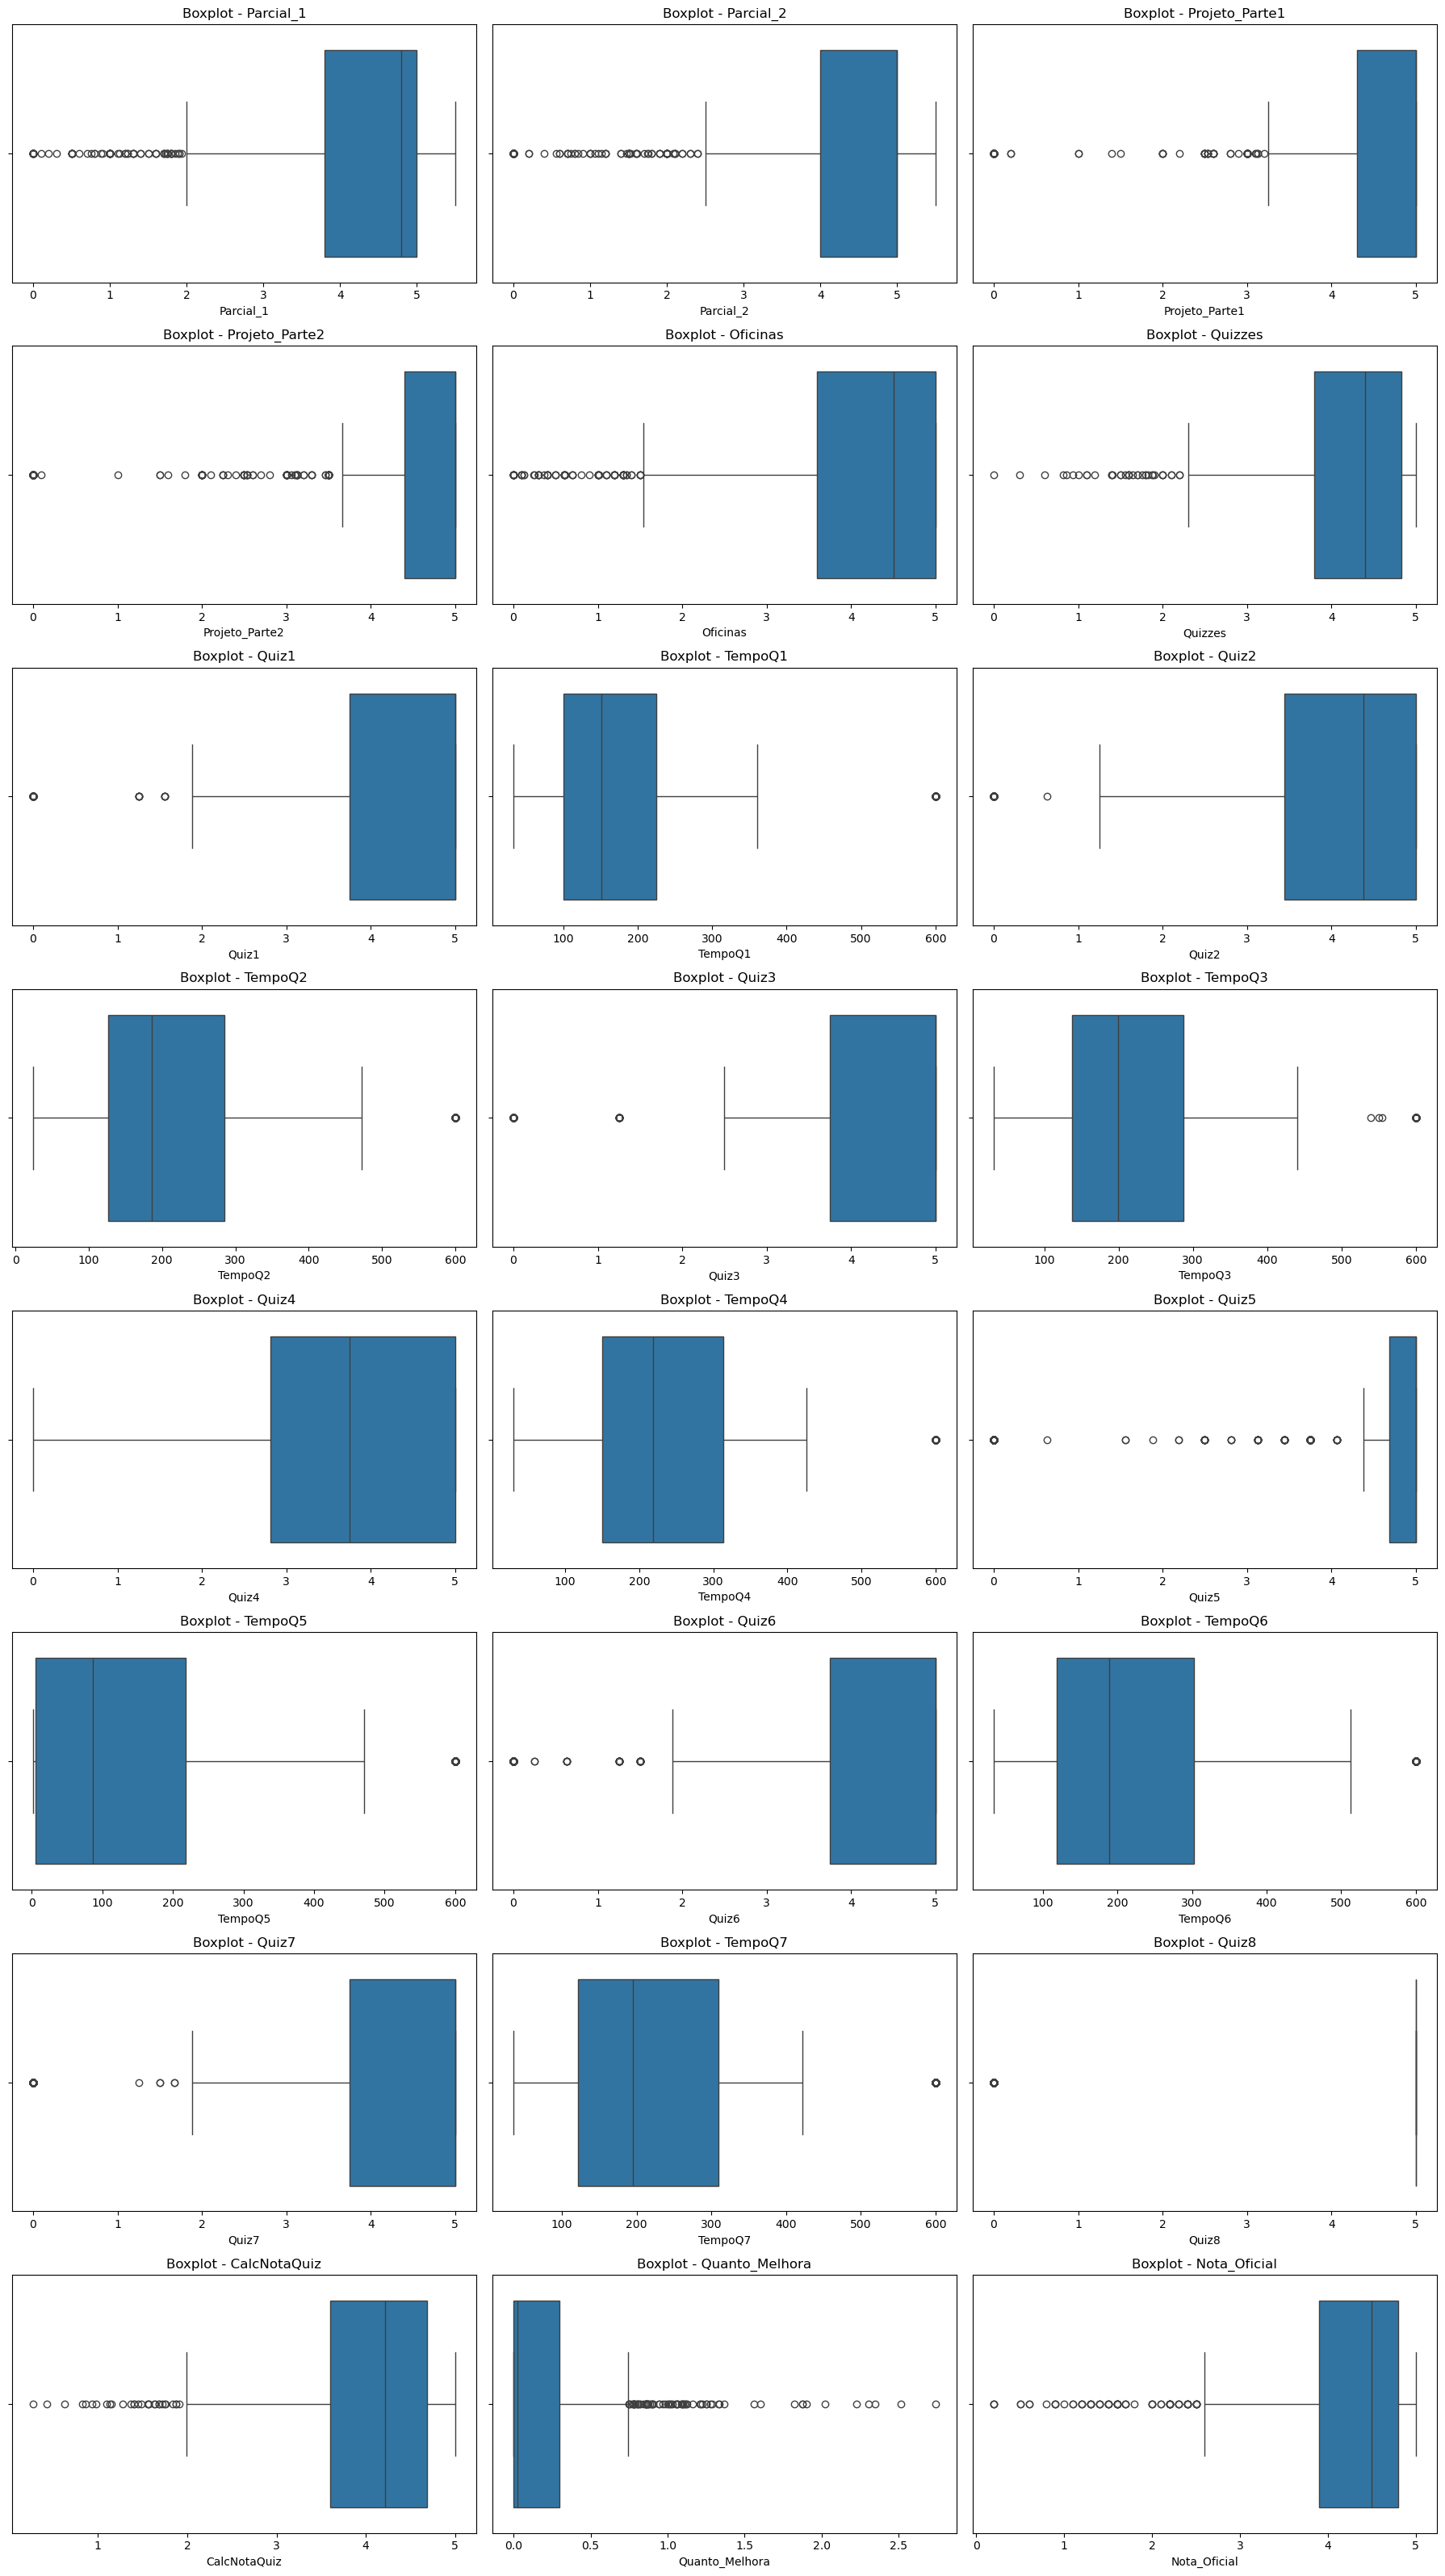

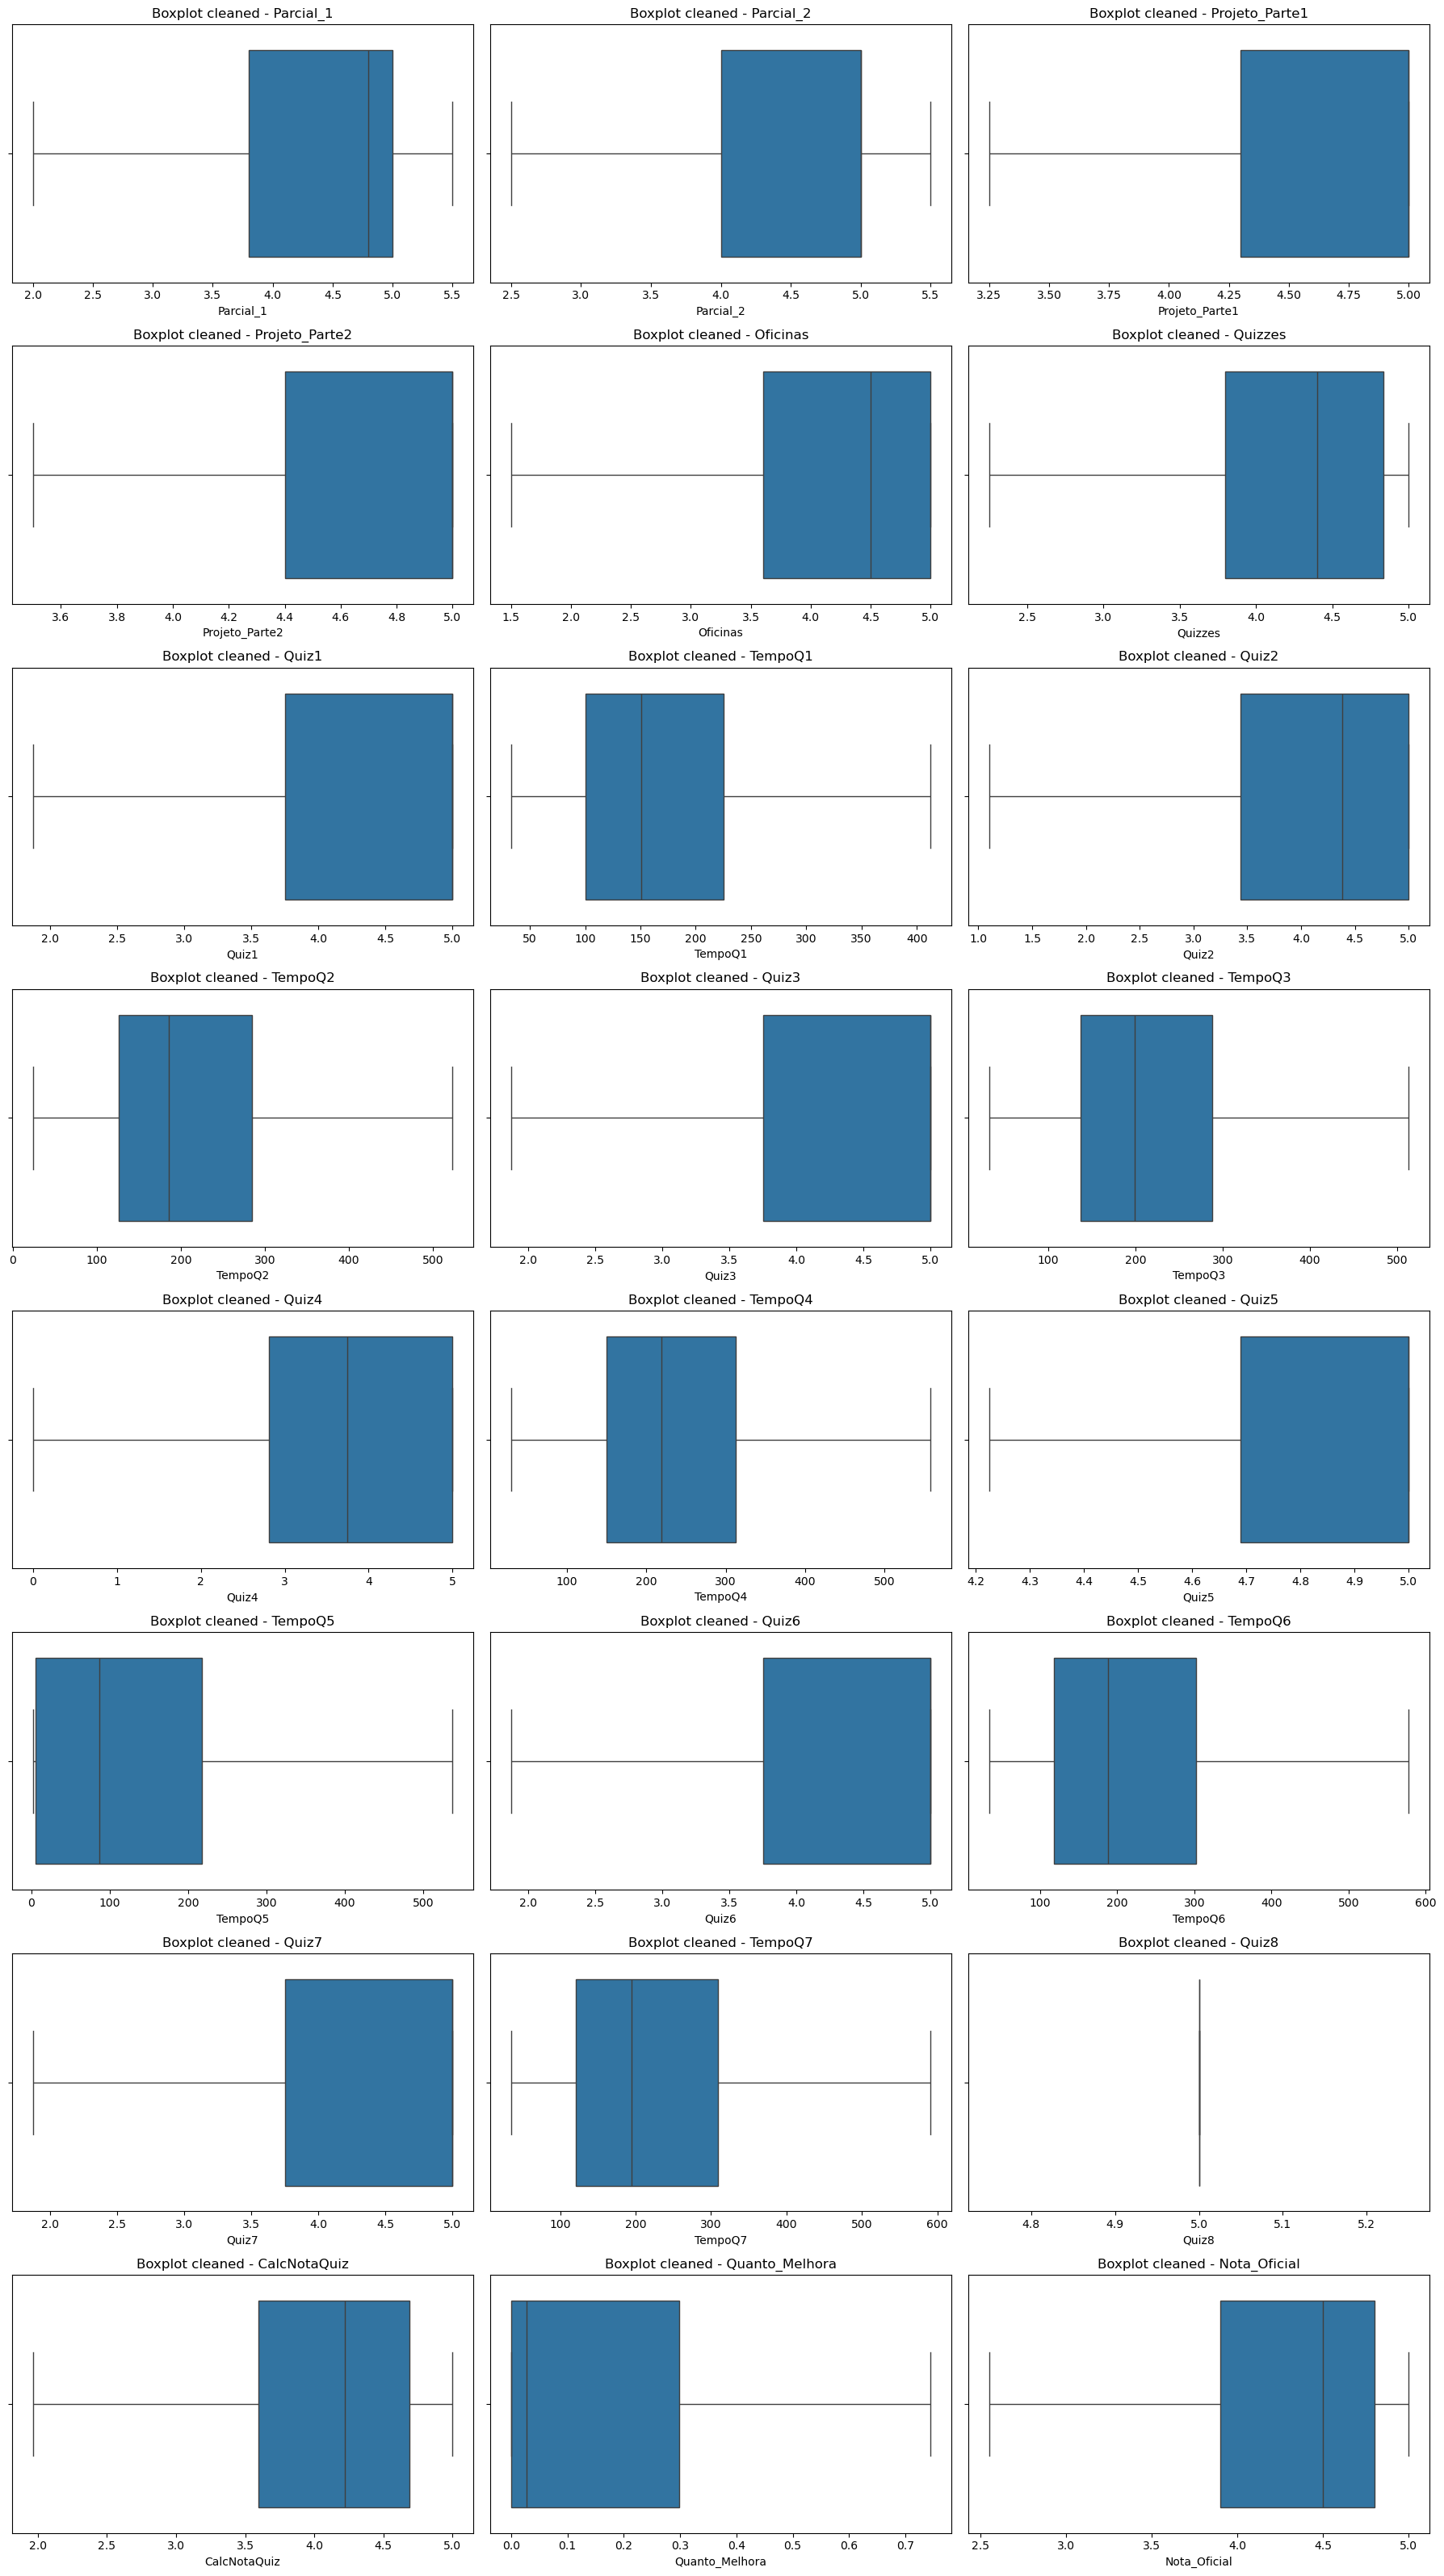

df_consolidado: (1375, 34)
df_onehot: (1375, 42)


In [5]:
# 1) Carregar Excel
df1_raw = pd.read_excel(XLSX1_PATH, sheet_name=SHEET_INDEX)
df2_raw = pd.read_excel(XLSX2_PATH, sheet_name=SHEET_INDEX)

# 2) Padronizar valores/nomes
df1 = padroniza_df(df1_raw)
df2 = padroniza_df(df2_raw)

# 3) Converter tempos para segundos
df1 = converte_colunas_tempo(df1)
df2 = converte_colunas_tempo(df2)

# 4) Filtrar apenas alunos com algum quiz e remover colunas de datas
df1_presentes = filtra_alunos_presentes(df1)
df2_presentes = filtra_alunos_presentes(df2)

# 5) Concatenar
df_consolidado = pd.concat([df1_presentes, df2_presentes], ignore_index=True)

# 5.1) Limpar outliers das colunas numéricas
df_numeric_clean = remove_outliers(df_consolidado)  # faz clip nos outliers
# Substituir as colunas numéricas no df_consolidado
df_consolidado[df_numeric_clean.columns] = df_numeric_clean

# 6) Remover linhas com STEM ausente, replicando lógica original
if "STEM" in df_consolidado.columns:
    df_consolidado = df_consolidado.dropna(subset=["STEM"])

# 7) One-Hot
cat_cols = ["Tipo_Documento", "Idade", "Genero", "STEM", "MelhoraNotaQuizzes", "Aprovou"]
encoder_info = fit_onehot_encoder(df_consolidado, cat_cols)
df_onehot = aplica_onehot(df_consolidado, encoder_info)

# 8) Estatísticas
tabela_stats = estatisticas_basicas(df_consolidado)

# Amostras
print("df_consolidado:", df_consolidado.shape)
print("df_onehot:", df_onehot.shape)


Heatmap de correlação (numéricas)

<Axes: >

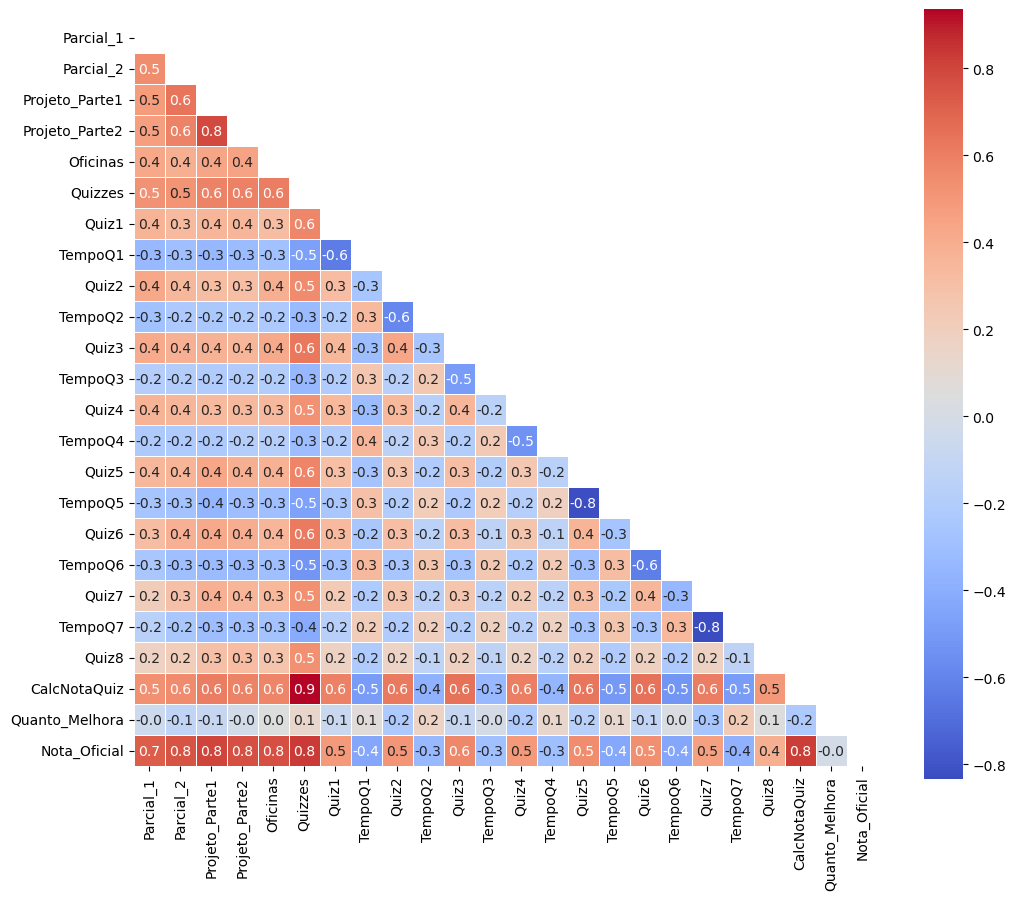

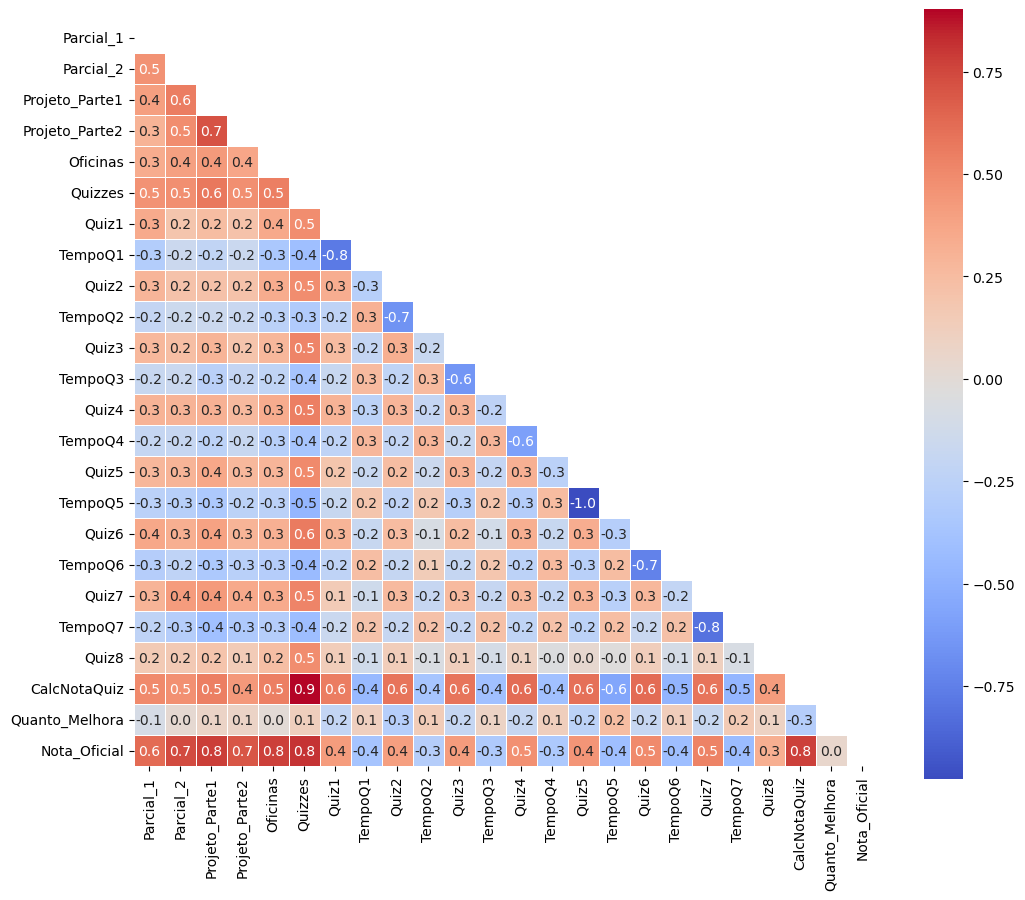

In [6]:
#Identificando colunas numéricas
numerical_cols1 = df1.select_dtypes(include = 'number').columns
numerical_cols2 = df2.select_dtypes(include = 'number').columns

numerical_cols1 = numerical_cols1.drop('Grupo')
numerical_cols2 = numerical_cols2.drop('Grupo')

#crianco a tabela de correlação
correlation1 = df1[numerical_cols1].corr()
correlation2 = df2[numerical_cols2].corr()


# tirando a parte desnecessária que estará no heatmap
mask1 = np.triu(np.ones_like(correlation1, dtype=bool))
mask2 = np.triu(np.ones_like(correlation2, dtype=bool))

# plotando os heatmaps
fig1, ax1 = plt.subplots(figsize=(12, 10))
sns.heatmap(correlation1, annot=True, fmt='.1f', mask=mask1, square=True, linewidths=.5, ax=ax1, cmap='coolwarm')

fig2, ax2 = plt.subplots(figsize=(12, 10))
sns.heatmap(correlation2, annot=True, fmt='.1f', mask=mask1, square=True, linewidths=.5, ax=ax2, cmap='coolwarm')

Remover dummies “baseline” (evitar dummy trap em modelos lineares)

In [7]:
# Remoção segura: só dropa se existir
baselines = ["STEM_No", "MelhoraNotaQuizzes_False", "Idade_Menor", "Aprovou_Reprovou", 'Genero_Feminino']
drop_list = [c for c in baselines if c in df_onehot.columns]
df_onehot = df_onehot.drop(columns=drop_list)
print("Dummies baseline removidas:", drop_list)
print("df_onehot (após remoção):", df_onehot.shape)

Dummies baseline removidas: ['STEM_No', 'MelhoraNotaQuizzes_False', 'Idade_Menor', 'Aprovou_Reprovou', 'Genero_Feminino']
df_onehot (após remoção): (1375, 37)


Analisando a correlação entre variáveis - Curso da área e quantidade de aprovados

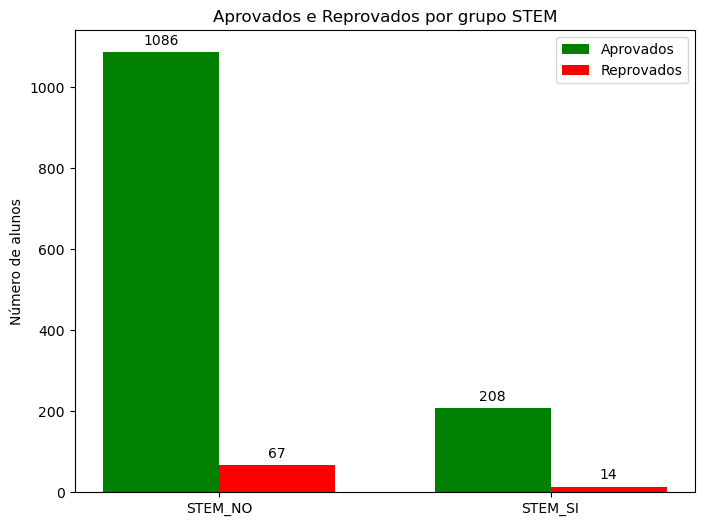

In [8]:


sumario = df_onehot.groupby('STEM_SI')['Aprovou_Aprovou'].value_counts().unstack(fill_value=0)

labels = ['STEM_NO', 'STEM_SI']
aprovados = sumario[1].values
reprovados = sumario[0].values
x = np.arange(len(labels))
width = 0.35
fig, ax = plt.subplots(figsize=(8,6))

# Barras lado a lado
rects1 = ax.bar(x - width/2, aprovados, width, label='Aprovados', color='green')
rects2 = ax.bar(x + width/2, reprovados, width, label='Reprovados', color='red')

# Adicionar números em cima de cada barra
ax.bar_label(rects1, padding=3)  # padding é o espaço entre a barra e o número
ax.bar_label(rects2, padding=3)

# Labels e título
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Número de alunos')
ax.set_title('Aprovados e Reprovados por grupo STEM')
ax.legend()

plt.show()



Gênero e taxa de aprovados

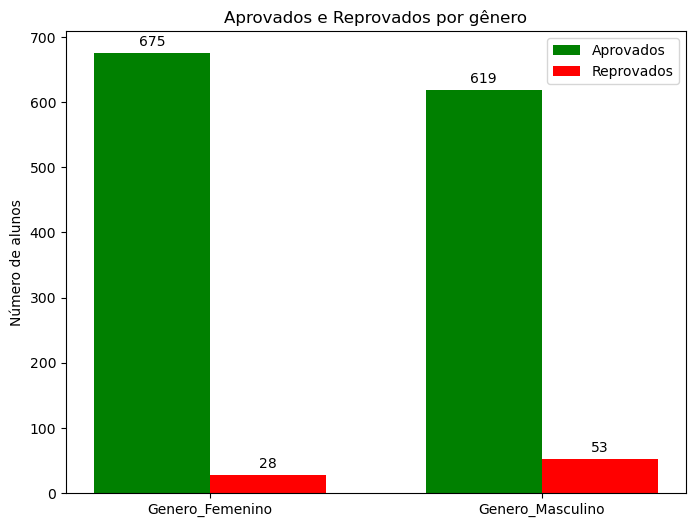

In [9]:

sumario = df_onehot.groupby('Genero_Masculino')['Aprovou_Aprovou'].value_counts().unstack(fill_value=0)

labels = ['Genero_Femenino', 'Genero_Masculino']
aprovados = sumario[1].values
reprovados = sumario[0].values
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8,6))

# Barras lado a lado
rects1 = ax.bar(x - width/2, aprovados, width, label='Aprovados', color='green')
rects2 = ax.bar(x + width/2, reprovados, width, label='Reprovados', color='red')

# Adicionar números em cima de cada barra
ax.bar_label(rects1, padding=3)  # padding é o espaço entre a barra e o número
ax.bar_label(rects2, padding=3)

# Labels e título
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Número de alunos')
ax.set_title('Aprovados e Reprovados por gênero')
ax.legend()

plt.show()


Notas de cada quiz e taxa de reprovação

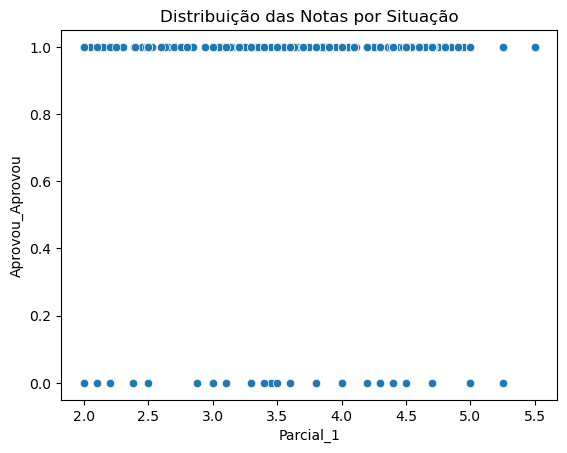

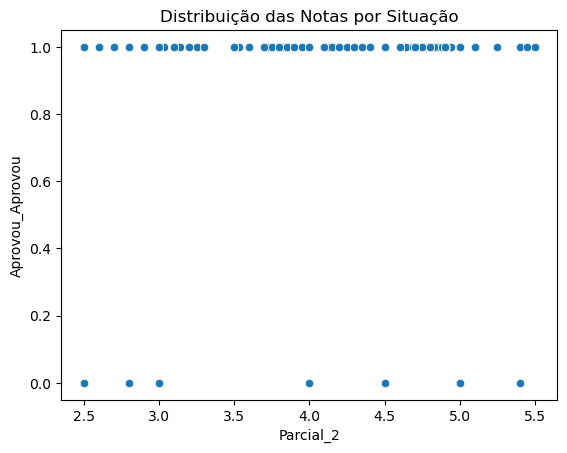

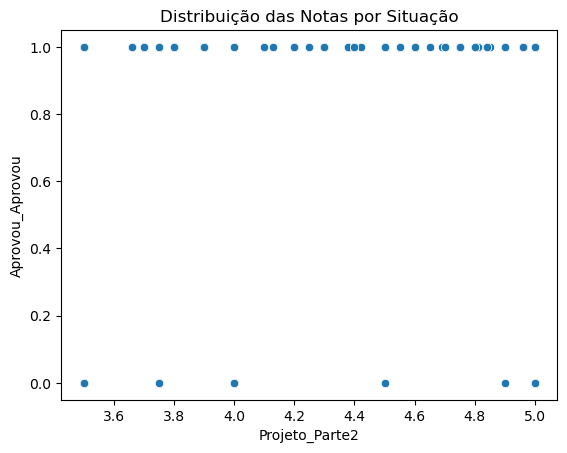

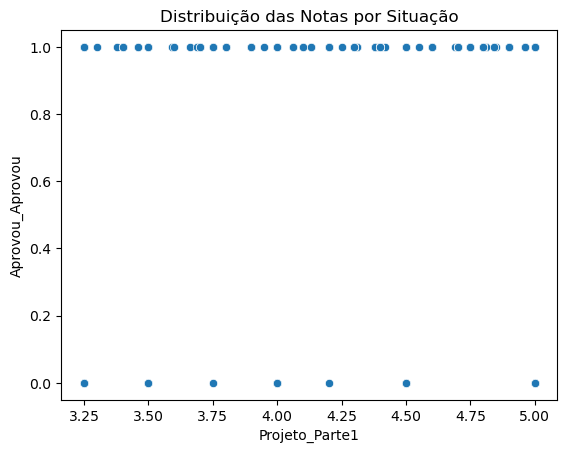

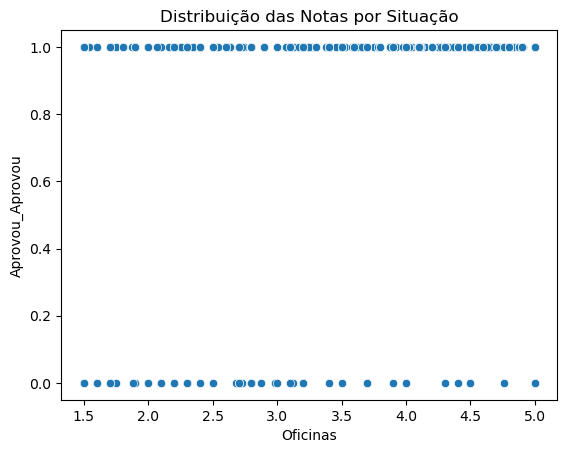

In [10]:
notas = ['Parcial_1','Parcial_2','Projeto_Parte2','Projeto_Parte1','Oficinas']

for n in notas:
    sns.scatterplot(x=df_onehot[n], y='Aprovou_Aprovou', data=df_onehot)
    plt.title('Distribuição das Notas por Situação')
    plt.show()

Histograma e Violin Plot [Oficinas/Talleres]

In [11]:
# Criar subplots com 2 linhas e 1 coluna para acomodar o histograma e o violin plot
fig = make_subplots(
    rows=2,
    cols=1,
    subplot_titles=('Histograma de Oficinas', 'Violin Plot de Oficinas'), # Títulos para cada subplot
    vertical_spacing=0.15  # Aumentar o espaço vertical entre os subplots para evitar sobreposição de títulos/rótulos
)

# Adicionar o histograma para a coluna 'Oficinas'
fig.add_trace(
    go.Histogram(
        x=df_consolidado['Oficinas'], # Dados para o histograma
        nbinsx=30, # Número de bins no histograma
        name='', # Nome da trace (não exibido com showlegend=False)
        marker=dict(
            color='#004066', # Cor das barras do histograma
            opacity=0.8, # Opacidade das barras
            line=dict(color='black', width=1) # Adiciona borda preta às barras
        )
    ),
    row=1, col=1 # Posicionar no primeiro subplot (primeira linha, primeira coluna)
)

# Adicionar o violin plot para a coluna 'Oficinas'
fig.add_trace(
    go.Violin(
        y=df_consolidado['Oficinas'], # Dados para o violin plot
        name='', # Nome da trace
        marker_color='#004066', # Cor do violin plot
        opacity=0.8, # Opacidade
        box_visible=True, # Mostrar box plot dentro do violin plot
        meanline_visible=True # Mostrar linha da média
    ),
    row=2, col=1 # Posicionar no segundo subplot (segunda linha, primeira coluna)
)


# Atualizar configurações gerais de layout do gráfico
fig.update_layout(
    title_text="Análise de Oficinas - Multiplot", # Título principal do gráfico
    height=900, # Altura do gráfico em pixels
    showlegend=False, # Não mostrar a legenda
    plot_bgcolor='white', # Cor de fundo da área de plotagem
    paper_bgcolor='white', # Cor de fundo do papel (área fora da plotagem)
    font=dict(family="Arial"), # Fonte do texto do gráfico
    margin=dict(t=80) # Aumentar margem superior para o título principal não ficar muito próximo do topo
)

# Atualizar layout dos eixos do histograma
fig.update_xaxes(title_text="Nota de Oficinas", row=1, col=1, gridcolor='lightgray', zerolinecolor='lightgray') # Rótulo do eixo X
fig.update_yaxes(title_text="Frequência", row=1, col=1, gridcolor='lightgray', zerolinecolor='lightgray') # Rótulo do eixo Y

# Atualizar layout dos eixos do violin plot
fig.update_xaxes(title_text="", row=2, col=1, gridcolor='lightgray', zerolinecolor='lightgray') # Remover rótulo do eixo X para evitar redundância
fig.update_yaxes(title_text="Nota de Oficinas", row=2, col=1, gridcolor='lightgray', zerolinecolor='lightgray') # Rótulo do eixo Y


fig.update_layout(height=700, width=1000) # Ajustar altura e largura finais do gráfico
# Mostrar o gráfico
fig.show()

Histograma e Violin Plot [Nota Oficial/Calificación_Oficial]

In [12]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np


# Criar subplots com 2 linhas e 1 coluna para acomodar o histograma e o violin plot
fig = make_subplots(
    rows=2,
    cols=1,
    subplot_titles=('Histograma de Nota Oficial', 'Violin Plot de Nota Oficial'), # Títulos para cada subplot
    vertical_spacing=0.15 # Aumentar o espaço vertical entre os subplots para evitar sobreposição de títulos/rótulos
)

# Adicionar o histograma para a coluna 'Nota_Oficial'
fig.add_trace(
    go.Histogram(
        x=df_consolidado['Nota_Oficial'], # Dados para o histograma
        nbinsx=30, # Número de bins no histograma
        name='', # Nome da trace (não exibido com showlegend=False)
        marker=dict(
            color='#004066', # Cor das barras do histograma
            opacity=0.8, # Opacidade das barras
            line=dict(color='black', width=1) # Adiciona borda preta às barras
        )
    ),
    row=1, col=1 # Posicionar no primeiro subplot (primeira linha, primeira coluna)
)

# Adicionar o violin plot para a coluna 'Nota_Oficial'
fig.add_trace(
    go.Violin(
        y=df_consolidado['Nota_Oficial'], # Dados para o violin plot
        name='', # Nome da trace
        marker_color='#004066', # Cor do violin plot
        opacity=0.8, # Opacidade
        box_visible=True, # Mostrar box plot dentro do violin plot
        meanline_visible=True # Mostrar linha da média
    ),
    row=2, col=1 # Posicionar no segundo subplot (segunda linha, primeira coluna)
)


# Atualizar configurações gerais de layout do gráfico
fig.update_layout(
    title_text="Análise de Nota Oficial - Multiplot", # Título principal do gráfico
    height=900, # Altura do gráfico em pixels
    showlegend=False, # Não mostrar a legenda
    plot_bgcolor='white', # Cor de fundo da área de plotagem
    paper_bgcolor='white', # Cor de fundo do papel (área fora da plotagem)
    font=dict(family="Arial"), # Fonte do texto do gráfico
    margin=dict(t=80) # Aumentar margem superior para o título principal não ficar muito próximo do topo
)

# Atualizar layout dos eixos do histograma
fig.update_xaxes(title_text="Nota Oficial", row=1, col=1, gridcolor='lightgray', zerolinecolor='lightgray') # Rótulo do eixo X
fig.update_yaxes(title_text="Frequência", row=1, col=1, gridcolor='lightgray', zerolinecolor='lightgray') # Rótulo do eixo Y

# Atualizar layout dos eixos do violin plot
fig.update_xaxes(title_text="", row=2, col=1, gridcolor='lightgray', zerolinecolor='lightgray') # Remover rótulo do eixo X para evitar redundância
fig.update_yaxes(title_text="Nota Oficial", row=2, col=1, gridcolor='lightgray', zerolinecolor='lightgray') # Rótulo do eixo Y


fig.update_layout(height=700, width=1000) # Ajustar altura e largura finais do gráfico
# Mostrar o gráfico
fig.show()

Histograma e Violin Plot [CalcNotaQuiz]

In [13]:
# Criar subplots com 2 linhas e 1 coluna para acomodar o histograma e o violin plot
fig = make_subplots(
    rows=2,
    cols=1,
    subplot_titles=('Histograma de CalcNotaQuiz', 'Violin Plot de CalcNotaQuiz'), # Títulos para cada subplot
    vertical_spacing=0.15 # Aumentar o espaço vertical entre os subplots para evitar sobreposição de títulos/rótulos
)

# Adicionar o histograma para a coluna 'CalcNotaQuiz'
fig.add_trace(
    go.Histogram(
        x=df_consolidado['CalcNotaQuiz'], # Dados para o histograma
        nbinsx=30, # Número de bins no histograma
        name='', # Nome da trace (não exibido com showlegend=False)
        marker=dict(
            color='#004066', # Cor das barras do histograma
            opacity=0.8, # Opacidade das barras
            line=dict(color='black', width=1) # Adiciona borda preta às barras
        )
    ),
    row=1, col=1 # Posicionar no primeiro subplot (primeira linha, primeira coluna)
)

# Adicionar o violin plot para a coluna 'CalcNotaQuiz'
fig.add_trace(
    go.Violin(
        y=df_consolidado['CalcNotaQuiz'], # Dados para o violin plot
        name='', # Nome da trace
        marker_color='#004066', # Cor do violin plot
        opacity=0.8, # Opacidade
        box_visible=True, # Mostrar box plot dentro do violin plot
        meanline_visible=True # Mostrar linha da média
    ),
    row=2, col=1 # Posicionar no segundo subplot (segunda linha, primeira coluna)
)


# Atualizar configurações gerais de layout do gráfico
fig.update_layout(
    title_text="Análise de CalcNotaQuiz - Multiplot", # Título principal do gráfico
    height=900, # Altura do gráfico em pixels
    showlegend=False, # Não mostrar a legenda
    plot_bgcolor='white', # Cor de fundo da área de plotagem
    paper_bgcolor='white', # Cor de fundo do papel (área fora da plotagem)
    font=dict(family="Arial"), # Fonte do texto do gráfico
    margin=dict(t=80) # Aumentar margem superior para o título principal não ficar muito próximo do topo
)

# Atualizar layout dos eixos do histograma
fig.update_xaxes(title_text="Nota CalcNotaQuiz", row=1, col=1, gridcolor='lightgray', zerolinecolor='lightgray') # Rótulo do eixo X
fig.update_yaxes(title_text="Frequência", row=1, col=1, gridcolor='lightgray', zerolinecolor='lightgray') # Rótulo do eixo Y

# Atualizar layout dos eixos do violin plot
fig.update_xaxes(title_text="", row=2, col=1, gridcolor='lightgray', zerolinecolor='lightgray') # Remover rótulo do eixo X para evitar redundância
fig.update_yaxes(title_text="Nota CalcNotaQuiz", row=2, col=1, gridcolor='lightgray', zerolinecolor='lightgray') # Rótulo do eixo Y


fig.update_layout(height=700, width=1000) # Ajustar altura e largura finais do gráfico
# Mostrar o gráfico
fig.show()